In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ---------- 1. Load data ----------
df = pd.read_csv("/srv/disk00/ctadler/gift-eval/results/moiraie_base/all_models_results.csv")

# Rename metric columns for convenience
metric_cols = {
    "eval_metrics/MSE[mean]":                     "MSE",
    "eval_metrics/MAE[0.5]":                      "MAE",
    "eval_metrics/MASE[0.5]":                     "MASE",
    "eval_metrics/MAPE[0.5]":                     "MAPE",
    "eval_metrics/sMAPE[0.5]":                    "sMAPE",
    "eval_metrics/MSIS":                          "MSIS",
    "eval_metrics/RMSE[mean]":                    "RMSE",
    "eval_metrics/NRMSE[mean]":                   "NRMSE",
    "eval_metrics/ND[0.5]":                       "ND",
    "eval_metrics/mean_weighted_sum_quantile_loss": "WQL",
}
df = df.rename(columns=metric_cols)
metrics = list(metric_cols.values())

# Clean model name → trial id
df["trial"] = df["model"].str.replace("moiraie_base_", "", regex=False)
# df["trial"] = df["model"]

In [3]:
# ---------- 2. Rank trials per (dataset, metric). Lower = better ----------
rank_df = (
    df.groupby("dataset")[metrics]
      .rank(method="min", ascending=True)      # 1 = best
      .join(df[["dataset", "trial", "domain"]])
)

# ---------- 3. Mean rank per trial per metric ----------
mean_rank = rank_df.groupby("trial")[metrics].mean().round(2)
print("Mean rank across datasets (1 = best):")
print(mean_rank)

# Overall rank: average over all metrics
mean_rank["OVERALL"] = mean_rank.mean(axis=1)
mean_rank_sorted = mean_rank.sort_values("OVERALL")
print("\nOverall ranking:")
print(mean_rank_sorted[["OVERALL"]])

Mean rank across datasets (1 = best):
                 MSE   MAE  MASE  MAPE  sMAPE  MSIS  RMSE  NRMSE    ND   WQL
trial                                                                       
moiraic_base_11  1.4  1.42  1.42  1.47   1.37  1.68   1.4    1.4  1.42  1.48
moiraie_base_7   1.6  1.58  1.58  1.53   1.63  1.32   1.6    1.6  1.58  1.52

Overall ranking:
                 OVERALL
trial                   
moiraic_base_11    1.446
moiraie_base_7     1.554


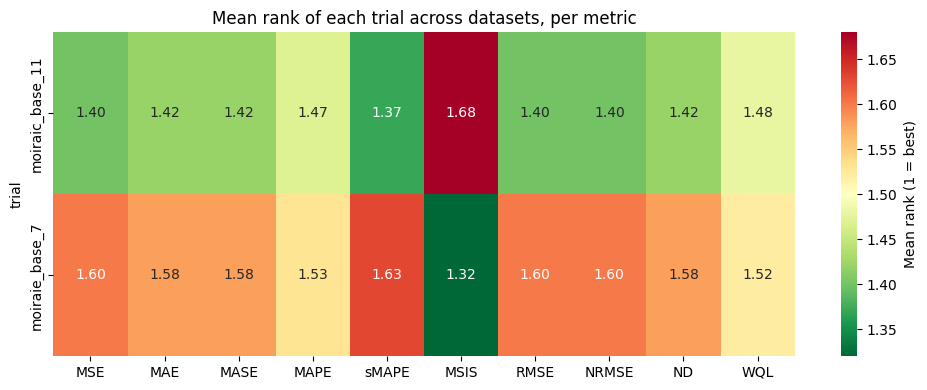

In [4]:
# ---------- 4. Plot: heatmap of mean rank (trial × metric) ----------
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(mean_rank_sorted.drop(columns="OVERALL"),
            annot=True, fmt=".2f", cmap="RdYlGn_r",
            cbar_kws={"label": "Mean rank (1 = best)"}, ax=ax)
ax.set_title("Mean rank of each trial across datasets, per metric")
plt.tight_layout()
# plt.savefig("rank_heatmap.png", dpi=150)
plt.show()

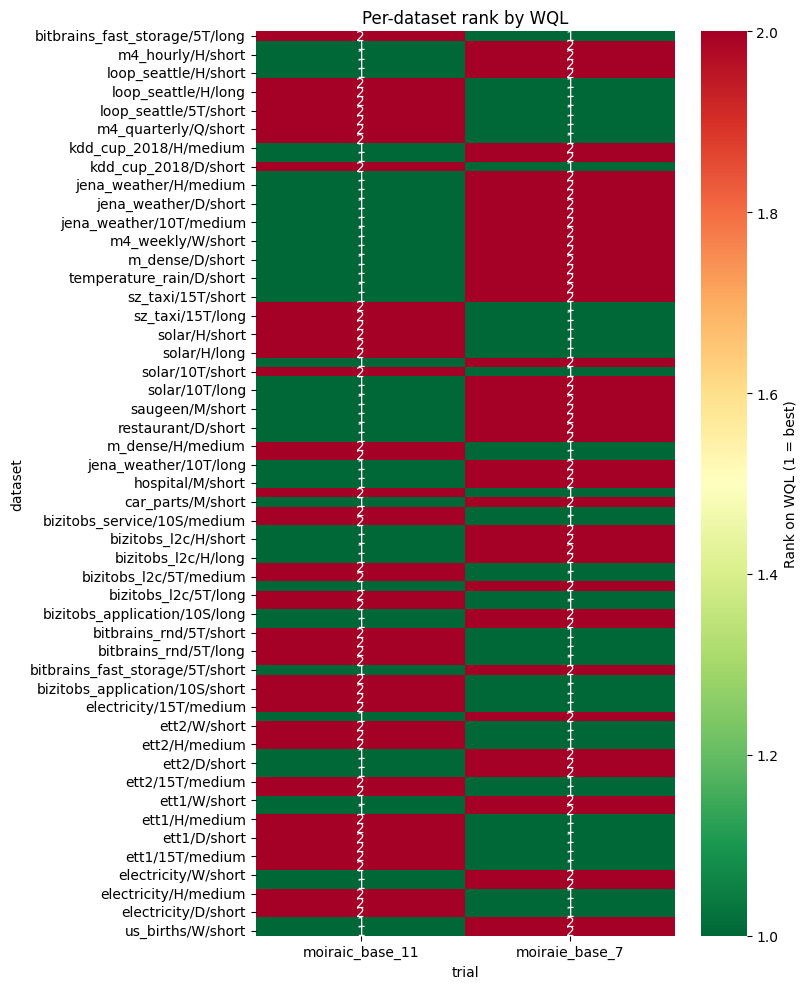

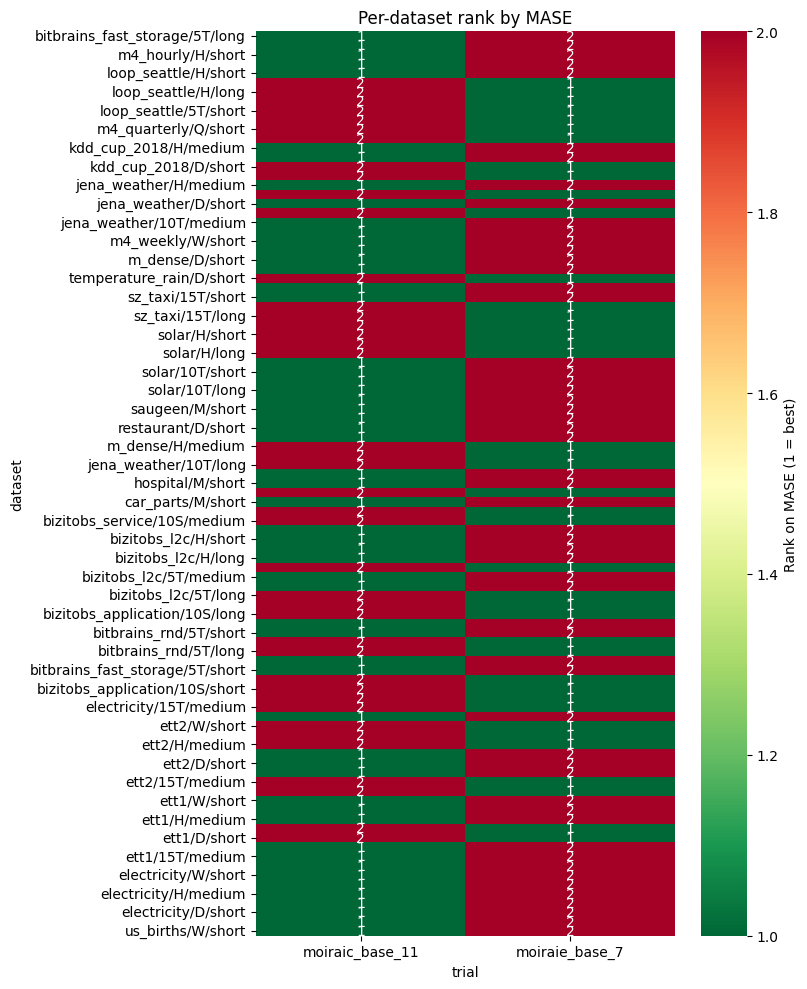

In [5]:
# ---------- 5. Plot: heatmap of rank per dataset, using a single metric ----------
# (pick a "headline" metric — WQL and MASE are typically good choices)
for headline in ["WQL", "MASE"]:
    pivot = (rank_df.pivot_table(index="dataset", columns="trial", values=headline))
    pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]   # sort datasets
    pivot = pivot[mean_rank_sorted.index]                        # sort trials by overall

    fig, ax = plt.subplots(figsize=(8, 10))
    sns.heatmap(pivot, annot=True, fmt=".0f", cmap="RdYlGn_r",
                cbar_kws={"label": f"Rank on {headline} (1 = best)"}, ax=ax)
    ax.set_title(f"Per-dataset rank by {headline}")
    plt.tight_layout()
    # plt.savefig(f"rank_per_dataset_{headline}.png", dpi=150)
    plt.show()

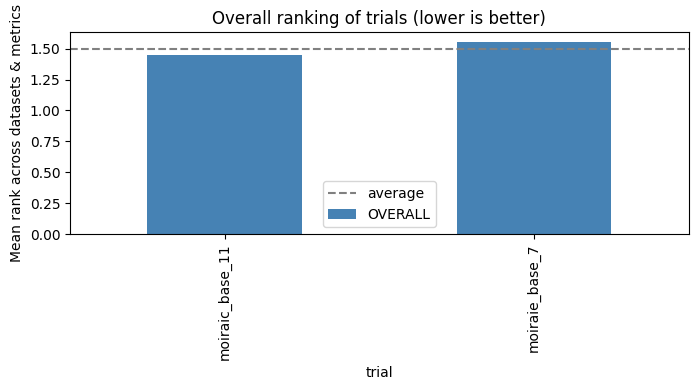

In [6]:
# ---------- 6. Plot: bar chart of overall mean rank ----------
fig, ax = plt.subplots(figsize=(7, 4))
mean_rank_sorted["OVERALL"].plot.bar(ax=ax, color="steelblue")
ax.set_ylabel("Mean rank across datasets & metrics")
ax.set_title("Overall ranking of trials (lower is better)")
ax.axhline(mean_rank_sorted["OVERALL"].mean(), ls="--", c="grey", label="average")
ax.legend()
plt.tight_layout()
# plt.savefig("overall_rank_bar.png", dpi=150)
plt.show()

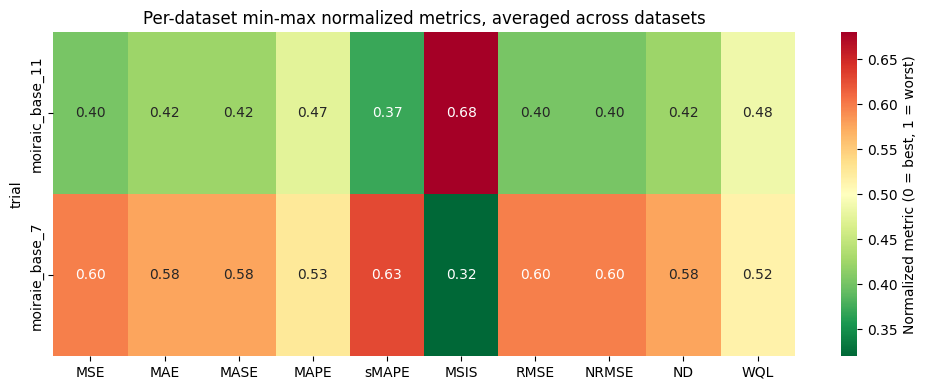

In [7]:
# ---------- 7. Normalized metric values (for magnitude-aware view) ----------
# Min-max normalize per dataset so all datasets are comparable on [0,1]
norm = df.copy()
for m in metrics:
    norm[m] = df.groupby("dataset")[m].transform(
        lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
    )
norm_mean = norm.groupby("trial")[metrics].mean().round(3)
norm_mean["OVERALL"] = norm_mean.mean(axis=1)
norm_mean = norm_mean.sort_values("OVERALL")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(norm_mean.drop(columns="OVERALL"),
            annot=True, fmt=".2f", cmap="RdYlGn_r",
            cbar_kws={"label": "Normalized metric (0 = best, 1 = worst)"}, ax=ax)
ax.set_title("Per-dataset min-max normalized metrics, averaged across datasets")
plt.tight_layout()
# plt.savefig("normalized_heatmap.png", dpi=150)
plt.show()

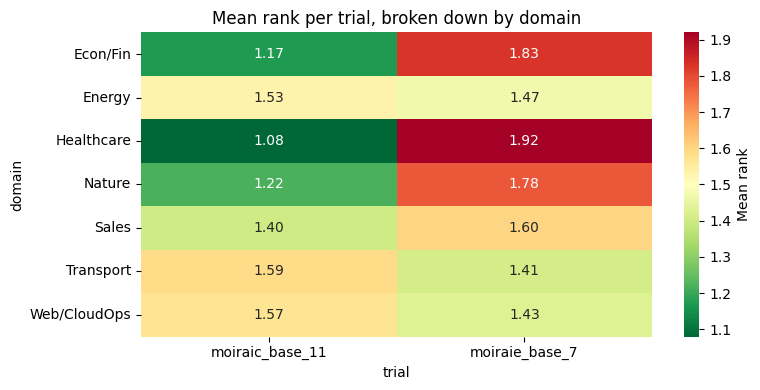

In [8]:
# ---------- 8. Per-domain breakdown ----------
domain_rank = (rank_df
               .groupby(["domain", "trial"])[metrics]
               .mean()
               .mean(axis=1)           # average over metrics
               .unstack("trial")
               .round(2))
domain_rank = domain_rank[mean_rank_sorted.index]

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(domain_rank, annot=True, fmt=".2f", cmap="RdYlGn_r",
            cbar_kws={"label": "Mean rank"}, ax=ax)
ax.set_title("Mean rank per trial, broken down by domain")
plt.tight_layout()
# plt.savefig("rank_by_domain.png", dpi=150)
plt.show()


Win rates (fraction of (dataset, metric) cells):
                  top1  top2
trial                       
moiraic_base_11  0.552   1.0
moiraie_base_7   0.448   1.0


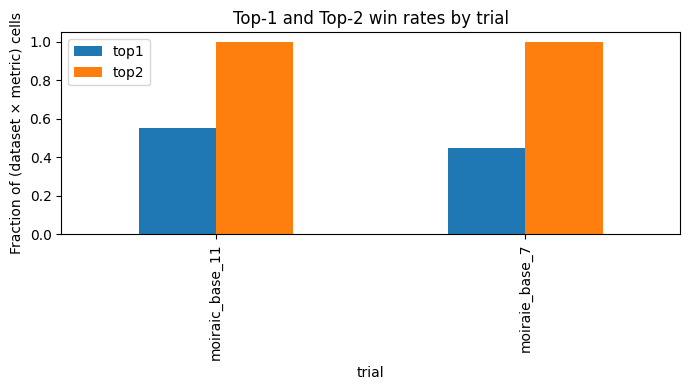

In [9]:
# ---------- 9. How often is each trial in the top-1 / top-2? ----------
wins = (rank_df.melt(id_vars=["dataset", "trial"], value_vars=metrics,
                     var_name="metric", value_name="rank")
        .assign(top1=lambda d: d["rank"] == 1,
                top2=lambda d: d["rank"] <= 2)
        .groupby("trial")[["top1", "top2"]].mean()
        .round(3)
        .sort_values("top1", ascending=False))
print("\nWin rates (fraction of (dataset, metric) cells):")
print(wins)

fig, ax = plt.subplots(figsize=(7, 4))
wins.plot.bar(ax=ax)
ax.set_ylabel("Fraction of (dataset × metric) cells")
ax.set_title("Top-1 and Top-2 win rates by trial")
plt.tight_layout()
# plt.savefig("win_rates.png", dpi=150)
plt.show()

plt.show()